In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('../mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np
import pandas as pds
import math

In [2]:
t=1
h = 1
lmax = np.sqrt(t**2+h**2)
l = np.linspace(t,lmax,1000)
a = 3
p = (t/l)*np.power((1-(t/l)**2),(a-1)/2)
cLMax = l<lmax
p = p[cLMax]
l = l[cLMax]

In [3]:
#print(p)

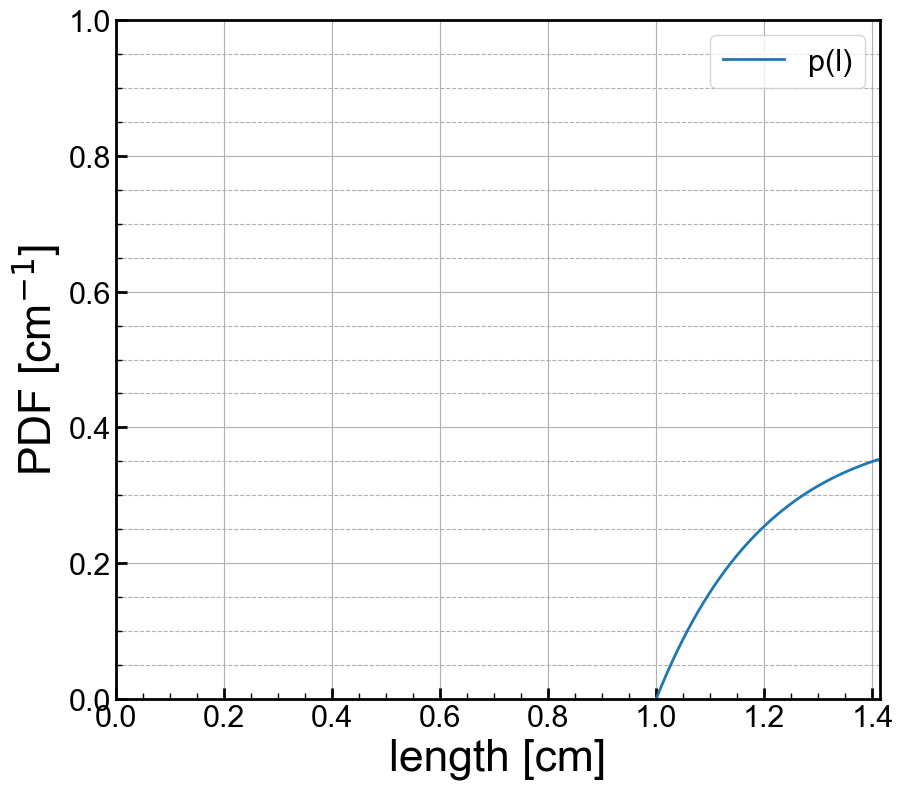

In [4]:
#set up a 1d plot
fig,axes = plt.subplots(1,1,figsize=(9.0,8.0),sharex=True)
ax1 = axes


#print(estring)
#ax1.plot(Er, dRlow,label='low res')
ax1.plot(l, p,label="p(l)")



ymin = 0
ymax = 1

blue = '#118DFA'
#ax1.fill_between(xcq,np.zeros(np.shape(xcq)),thist,step='mid',facecolor='b',alpha=0.4, \
#                 label='')

plt.grid()
ax1.set_yscale('linear')
#ax1.set_yscale('log')
ax1.set_xlim(0, lmax) 
ax1.set_ylim(ymin,ymax)
ax1.set_xlabel(r'length [cm]')
ax1.set_ylabel('PDF [cm$^{-1}$]')
ax1.grid(True)
ax1.yaxis.grid(True,which='minor',linestyle='--')
ax1.legend(loc=1,prop={'size':22})
#ax1.legend(bbox_to_anchor=(1.04,1),borderaxespad=0,prop={'size':22})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
#plt.savefig('figures/ne-recspec-Eee.png')
plt.show()

In [5]:
#the monte carlo way
L = 50
N = 10
X = np.random.uniform(-L,L,N)
Y = np.random.uniform(-L,L,N)
R = np.sqrt(X**2,Y**2)
print(R)

[39.17323994 32.71335756 44.09942063 43.94235383  1.56777549 14.38836042
 31.97337288  0.45972524 14.18107219 32.95148248]


In [6]:
from scipy import integrate
#def cos_int(x):
#  f = lambda u: (a+1)*np.power(u,a)
#  return integrate.quad(f,0,x)[0]

def cos_int(x):
    f = lambda u: (a + 1) * np.power(u, a)

    if np.isscalar(x):
        return integrate.quad(f, 0, x)[0]
    else:
        return np.array([integrate.quad(f, 0, xi)[0] for xi in x])

print(cos_int(0.9999999))

from scipy import optimize
#def inv_cos_int(y):
#  g = lambda v: cos_int(v)-y
#  return optimize.root(g,0.5).x[0]

def inv_cos_int(y):
    
    def solve_one(yi):
        g = lambda v: cos_int(v) - yi
        return optimize.root(g, 0.5).x[0]

    if np.isscalar(y):
        return solve_one(y)
    else:
        y = np.asarray(y)
        return np.array([solve_one(yi) for yi in y])

print(inv_cos_int([0.5,0.6]))
print(cos_int(0.8409))


0.9999996000000603
[0.84089642 0.88011174]
0.500008526066096


In [7]:
phi = np.random.uniform(-np.pi,np.pi,N)
inv_costhet = np.random.uniform(0,1,N)
costhet = inv_cos_int(inv_costhet)

In [8]:
print(costhet)

[0.87020437 0.89203197 0.87645242 0.96006701 0.98464647 0.81260535
 0.86398809 0.97516427 0.78663747 0.83719261]


In [9]:
lcomp = t/np.sqrt(1-costhet**2)

In [10]:
print(lcomp)

[2.02967003 2.21252497 2.07689291 3.57436291 5.72867629 1.7158123
 1.98604903 4.51502223 1.6196557  1.82846057]
